<a href="https://colab.research.google.com/github/karthikeyan15-bit/deeplearning_repo/blob/main/Lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


## Data Exploration and Preparation

First, let's inspect the directory structure of the downloaded dataset to understand how the images are organized. Then, we will load and preprocess the images for our CNN model.

In [ ]:
import os

# List the contents of the downloaded dataset directory
print("Dataset directory structure:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files[:3]: # Print only first 3 files to avoid overwhelming output
        print(f'{subindent}{f}')
    if len(files) > 3:
        print(f'{subindent}...(and {len(files)-3} more files)')

Dataset directory structure:
chest-xray-pneumonia/
    chest_xray/
        chest_xray/
            .DS_Store
            val/
                .DS_Store
                PNEUMONIA/
                    person1947_bacteria_4876.jpeg
                    person1946_bacteria_4875.jpeg
                    person1952_bacteria_4883.jpeg
                    ...(and 6 more files)
                NORMAL/
                    NORMAL2-IM-1431-0001.jpeg
                    NORMAL2-IM-1440-0001.jpeg
                    NORMAL2-IM-1442-0001.jpeg
                    ...(and 6 more files)
            test/
                .DS_Store
                PNEUMONIA/
                    person1676_virus_2892.jpeg
                    person1650_virus_2852.jpeg
                    person22_virus_55.jpeg
                    ...(and 387 more files)
                NORMAL/
                    NORMAL2-IM-0336-0001.jpeg
                    IM-0101-0001.jpeg
                    NORMAL2-IM-0337-0001.jpeg
                   

In [ ]:
import tensorflow as tf

# Define paths for train, validation, and test datasets
train_dir = os.path.join(path, 'chest_xray', 'train')
val_dir = os.path.join(path, 'chest_xray', 'val')
test_dir = os.path.join(path, 'chest_xray', 'test')

# Count images in each split and category
def count_images(directory):
    normal_count = len(os.listdir(os.path.join(directory, 'NORMAL')))
    pneumonia_count = len(os.listdir(os.path.join(directory, 'PNEUMONIA')))
    return normal_count, pneumonia_count

train_normal, train_pneumonia = count_images(train_dir)
val_normal, val_pneumonia = count_images(val_dir)
test_normal, test_pneumonia = count_images(test_dir)

print(f"Train set: Normal={train_normal}, Pneumonia={train_pneumonia}")
print(f"Validation set: Normal={val_normal}, Pneumonia={val_pneumonia}")
print(f"Test set: Normal={test_normal}, Pneumonia={test_pneumonia}")

Train set: Normal=1341, Pneumonia=3875
Validation set: Normal=8, Pneumonia=8
Test set: Normal=234, Pneumonia=390


### Loading and Preprocessing Images

We will use `tf.keras.preprocessing.image_dataset_from_directory` to efficiently load the images from their respective directories. This utility automatically infers the labels from the directory structure and can apply initial preprocessing steps like resizing and shuffling.

In [ ]:
# Define image dimensions and batch size
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Create image datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [ ]:
# Normalize image pixel values to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Visualize Data

Let's visualize a few example images from the training dataset to ensure the loading and preprocessing steps are correct.

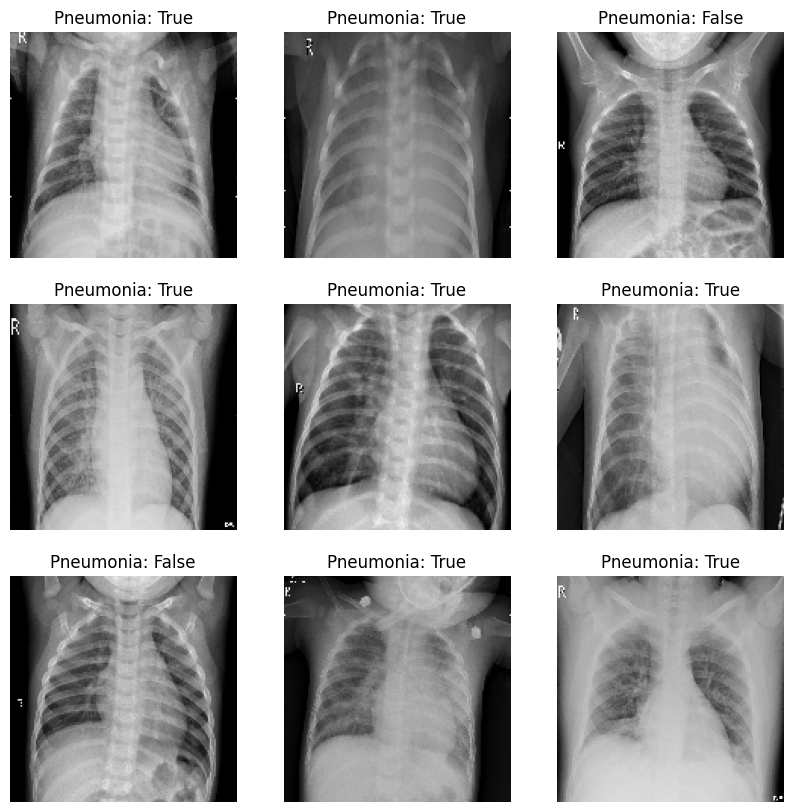

In [ ]:
import matplotlib.pyplot as plt

def show_images(dataset, num_images=9):
    plt.figure(figsize=(10, 10))
    for i, (images, labels) in enumerate(dataset.take(1)):
        for j in range(min(num_images, BATCH_SIZE)):
            ax = plt.subplot(3, 3, j + 1)
            plt.imshow(images[j].numpy())
            plt.title(f"Pneumonia: {bool(labels[j].numpy())}")
            plt.axis("off")
        break
    plt.show()

show_images(train_ds)

## Build the CNN Model

We will build a simple CNN model using `tf.keras.Sequential`. The model will consist of convolutional layers, pooling layers, and dense layers for classification. We'll start with a `Rescaling` layer to normalize pixel values if not already done, though we already applied it to our datasets.

In [ ]:
from tensorflow.keras import layers, models, Input

num_classes = 1 # Binary classification (Pneumonia or Normal)

model = models.Sequential([
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)), # Explicitly define input shape here
    # Data Augmentation Layers
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),

    layers.Conv2D(32, (3, 3), activation='relu'), # input_shape is now inferred
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Reshape((1, -1)), # -1 infers the dimension based on the input size
    layers.LSTM(128, activation='relu'), # LSTM layer
    layers.Dense(num_classes, activation='sigmoid') # Sigmoid for binary classification
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 1, 36992)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │    19,005,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,099,329 (72.86 MB)

 Trainable params: 19,099,329 (72.86 MB)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

After defining the model architecture, we need to compile it by specifying the optimizer, loss function, and metrics. For binary classification, `binary_crossentropy` is a suitable loss function.

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

## Train the Model

We will train the model using the `fit` method, passing in our training and validation datasets. We'll also specify the number of epochs and include callbacks for early stopping and model checkpointing to prevent overfitting and save the best model.

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.7889 - loss: 0.4727 - val_accuracy: 0.7500 - val_loss: 1.1671
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8520 - loss: 0.3426 - val_accuracy: 0.8125 - val_loss: 0.8723
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.8742 - loss: 0.2980 - val_accuracy: 0.7500 - val_loss: 0.8045
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.8863 - loss: 0.2676 - val_accuracy: 0.7500 - val_loss: 0.8570
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9015 - loss: 0.2415 - val_accuracy: 0.6875 - val_loss: 0.8020
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9128 - loss: 0.2214 - val_accuracy: 0.6875 - val_loss: 1.0133
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9199 - loss: 0.1992 - val_accuracy: 0.7500 - val_loss: 0.5998
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9235 - loss: 0.1957 - val_acc

## Evaluate the Model

After training, we'll evaluate the model's performance on the unseen test dataset to get an unbiased estimate of its generalization capabilities.

In [ ]:
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8718 - loss: 0.4060
Test Loss: 0.4060
Test Accuracy: 0.8718


## Plot Training History

Let's visualize the training and validation accuracy and loss over epochs to understand the model's learning process and identify potential overfitting.

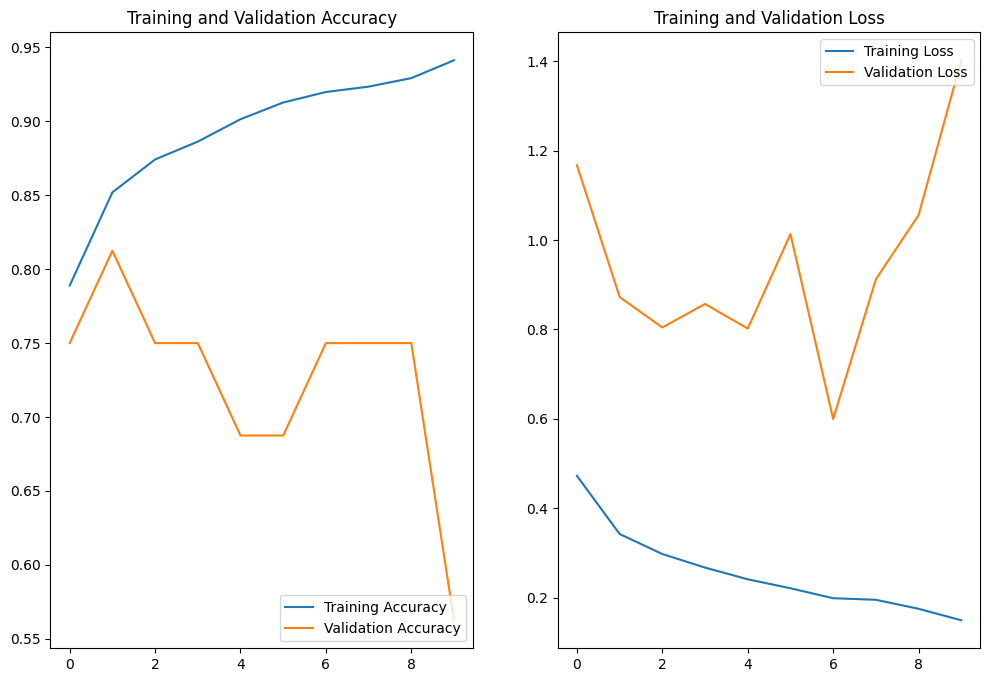

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

This concludes the initial model training and evaluation. Based on these results, we can consider further steps like hyperparameter tuning, data augmentation, or exploring more complex architectures. However, for now, we have a working model that can detect pneumonia from X-ray images.